In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
# load dataset (Pima Indians Diabetes Database)
# https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
pima = pd.read_csv("diabetes.csv", header=0, names=col_names)
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
# Split dataset in features and target variable
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 
'Age','Glucose','BloodPressure','DiabetesPedigreeFunction']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variabl
# Split dataset menjadi training set dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
random_state=1) # 70% training dan 30% test
# Membuat objek decision tree
clf = DecisionTreeClassifier()
# Train Decision Tree
clf = clf.fit(X_train,y_train)
# Hasil prediksi pada test set
y_pred = clf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6753246753246753


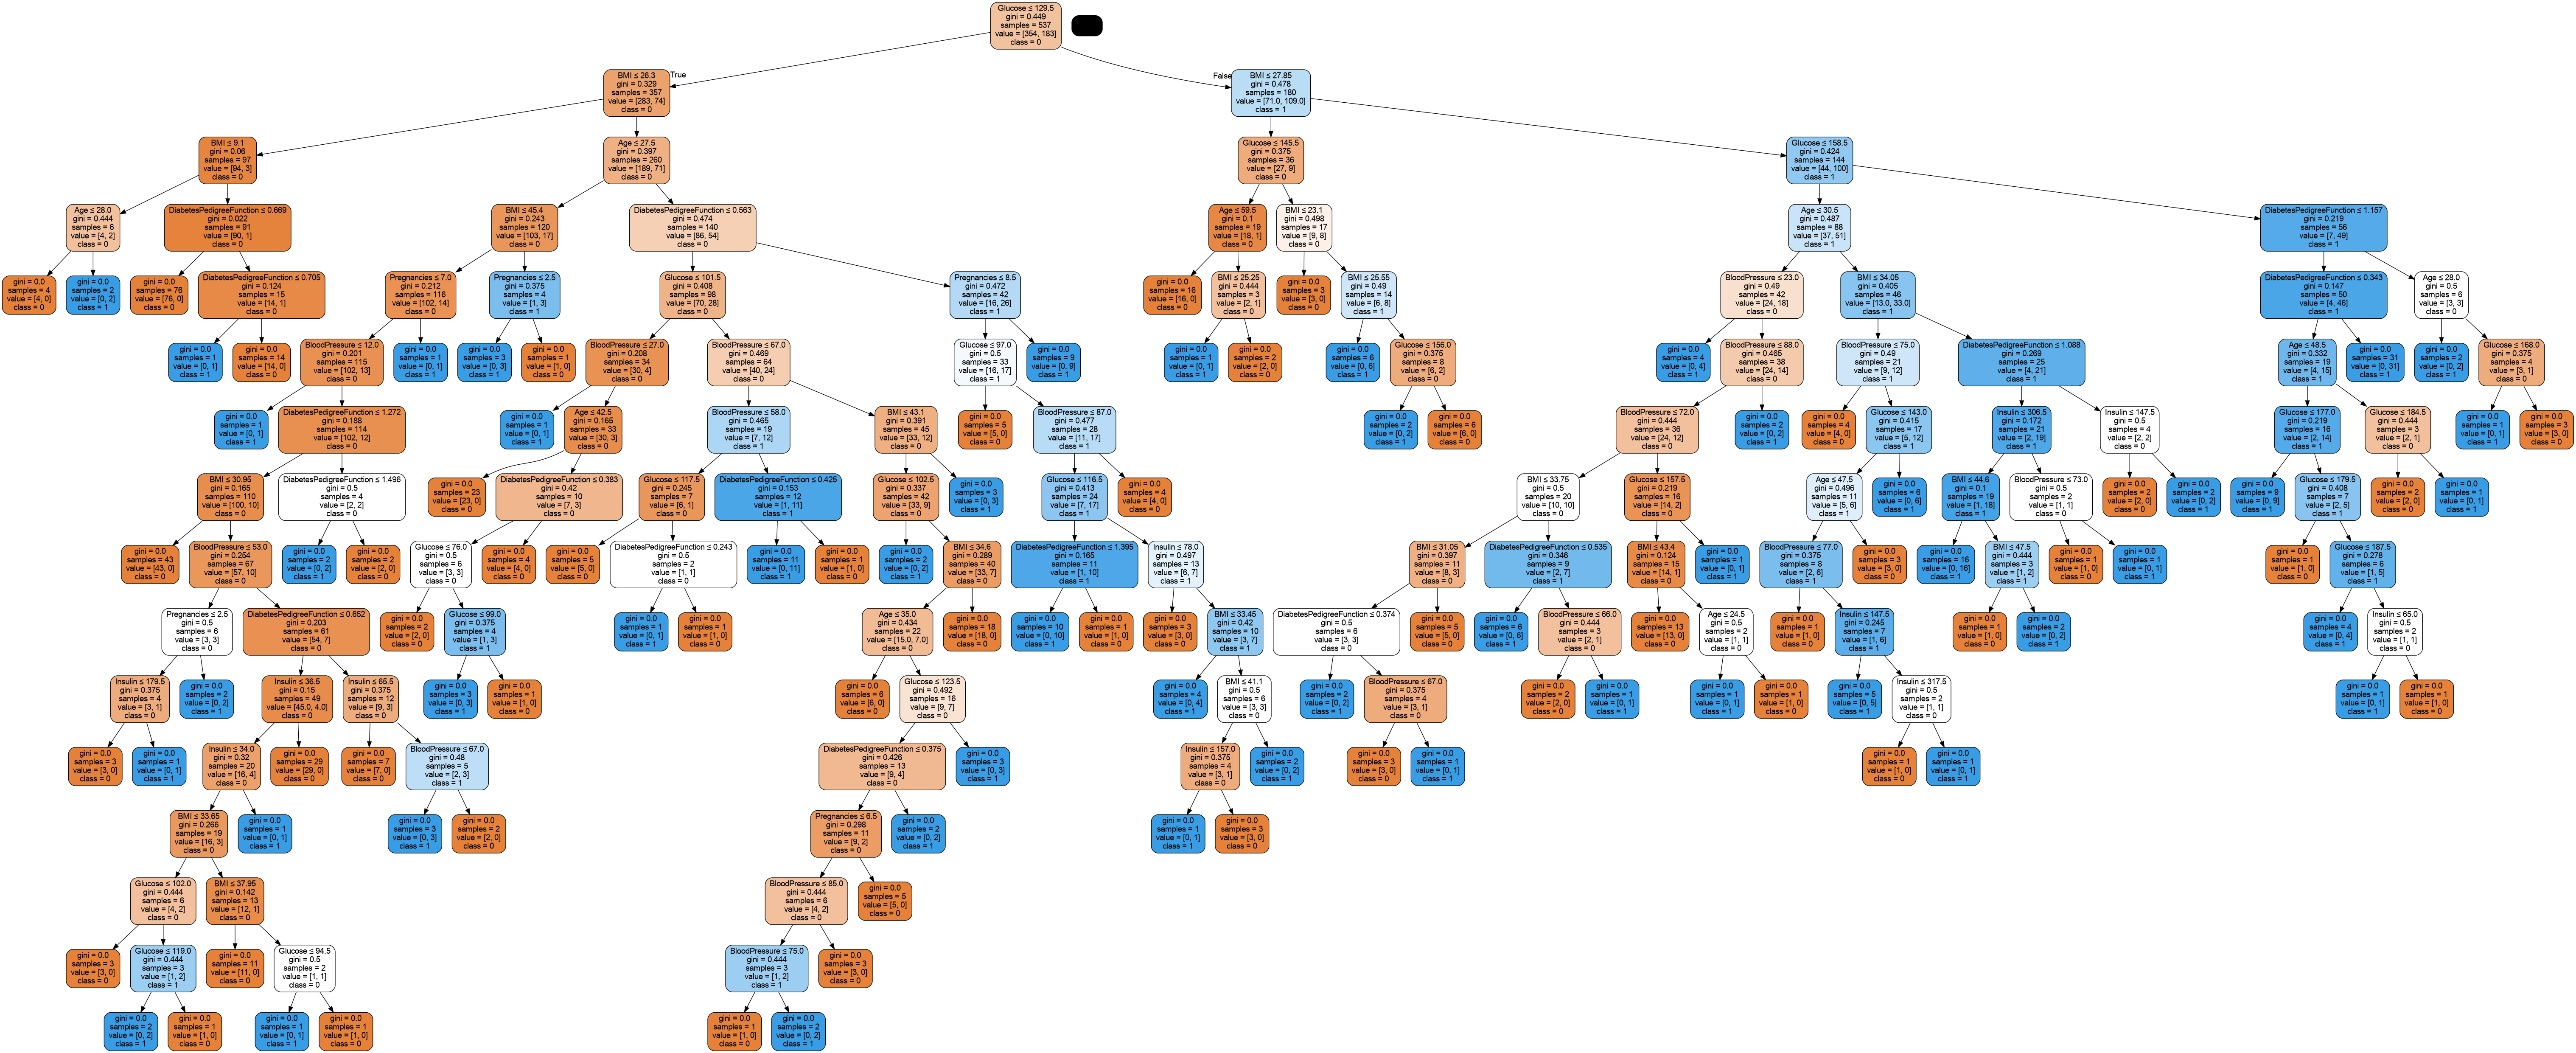

In [13]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, 
filled=True, rounded=True,
special_characters=True,feature_names =
feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue()) 
graph.write_png('diabetes_1.png')
Image(graph.create_png())

In [14]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)
# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)
#Predict the response for test dataset
y_pred = clf.predict(X_test)
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7705627705627706


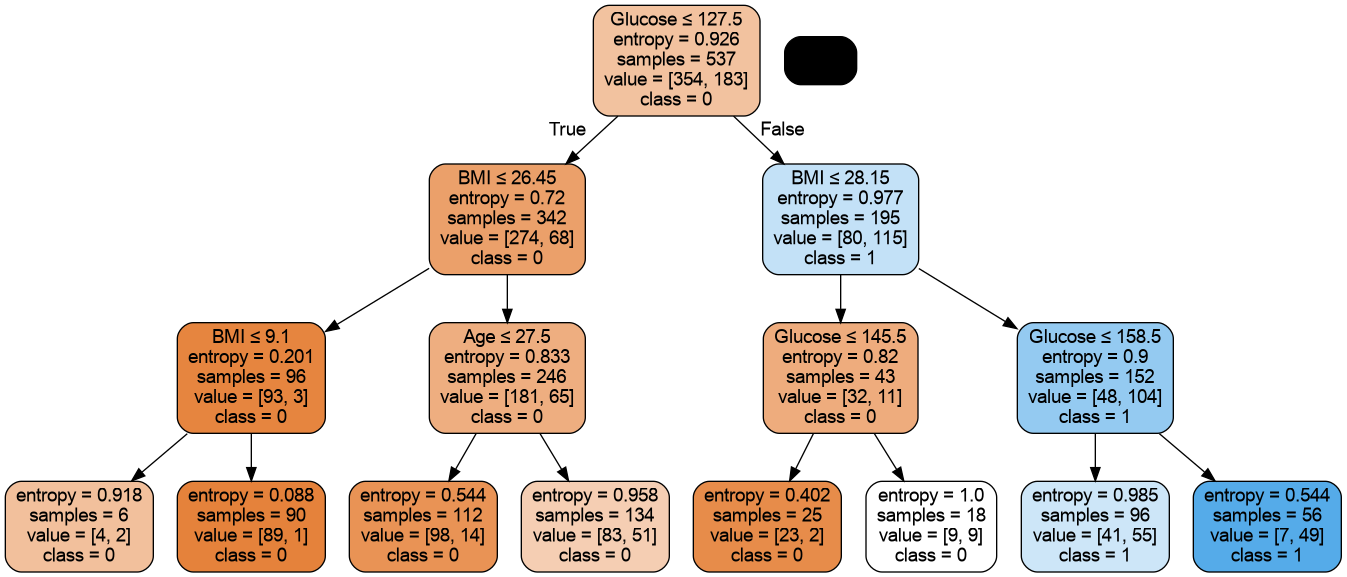

In [15]:
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, 
filled=True, rounded=True,
special_characters=True,feature_names =
feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue()) 
graph.write_png('diabetes_2.png')
Image(graph.create_png())

In [ ]:
import joblib
joblib.dump(clf, "model/diabetes_model")